## 97. Validation ICESat-2
0. Packages
1. Settings
2. Read Data
3. Plot data

### 0. Packages

In [1]:
# Packages
import colormaps as cmaps
import glob
import geopandas as gpd
import numpy as np
import os
import pandas as pd
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
from tqdm import tqdm

from resilientplotterclass import rpclass

### 1. Settings

In [ ]:
# File paths gtsm
file_path_gtsm_combined_zarr = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'
file_path_gtsm_stations_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_v2.parquet'

# File paths tiles
file_path_tiles_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v3.parquet'

# File path sdbs
file_path_sdbs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\05_reprojected\*.tif')
file_path_sdbs = [file_path for file_path in file_path_sdbs if not file_path.endswith('.tif.aux.xml')]
file_path_sdbs = {os.path.basename(file_path).split('_t')[0]: file_path for file_path in file_path_sdbs}

# Dir path icesat-2
dir_path_icesats = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\06_validation\ICESAT-2\full\tiles\tiles\*')
dir_path_icesats = {os.path.basename(dir_path): dir_path for dir_path in dir_path_icesats if os.path.isdir(dir_path)}

# File path gtsm stations
file_path_gtsm_stations = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_filtered_v2.parquet'
file_path_gtsm = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'

In [3]:
# Define guidelines
gls = {
    'general':
        {'crs': 'EPSG:4326',
         'cartopy_bounds': [3.5, 7, 51, 54],
         'cartopy_features': ['land', 'ocean', 'lakes', 'coastline', 'borders']},
    'geom_style':
        {'gtsm': {'color': 'blue', 'markersize': 10, 'label': 'GTSM stations'},
         'tiles': {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'label': 'Tiles'},
         'feasibility_map': {'facecolor': 'blue', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map'},
         'feasibility_map_ed': {'facecolor': 'red', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map (erosion-dilation)'},
         'tiles nearest distance': {'column': 'nearest_station_distance', 'vmin': 0, 'vmax': 50, 'cmap': 'Greens_r', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Distance to nearest GTSM station [km]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles intertidal coverage': {'column': 'intertidal_coverage', 'vmin': 0, 'vmax': 100, 'cmap': 'Greens', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Intertidal coverage [%]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles filtered': {'facecolor': 'none', 'edgecolor': 'red', 'linewidth': 1.5, 'label': 'Filtered tiles'}},
    'extent_style':
        {'waddenzee': {'xlim': [4.5703125 - 0.02, 5.625 + 0.02], 'ylim': [52.90890205 - 0.02, 53.54030739 + 0.02]},
         'le mont-saint-michel': {'xlim': [-2.109375 - 0.02, -1.40625 + 0.02], 'ylim': [48.45835188 - 0.02, 48.92249927 + 0.02]},
         #'shark Bay': {'xlim': [113.5546875 - 0.02, 114.2578125 + 0.02], 'ylim': [-26.11598592 - 0.02, -25.48295117 + 0.02]},
         #'giralia': {'xlim': [113.90625 - 0.02, 114.609375 + 0.02], 'ylim': [-22.59372606 - 0.02, -21.94304553 + 0.02]},
         #'brisbane': {'xlim': [152.9296875 - 0.02, 153.6328125 + 0.02], 'ylim': [-27.68352808 - 0.02, -27.05912578 + 0.02]},
         #'karumba': {'xlim': [139.921875 - 0.02, 140.625 + 0.02], 'ylim': [-17.97873309 - 0.02, -17.30868789 + 0.02]},
         #'netherlands': {'xlim': [3.5, 7], 'ylim': [51, 54]},
         #'europe': {'xlim': [-10, 10], 'ylim': [40, 60]},
         'global': {'xlim': [-180, 180], 'ylim': [-90, 90]}},
    }

# Set guidelines
rpc = rpclass(gls)

# Get guidelines
gls = rpc.get_guidelines()

# Get bounds and crs
crs = gls['general']['crs']
bounds = gls['general']['cartopy_bounds']

# Show guidelines
rpc.show_guidelines(open=False)

### Read Data

In [4]:
# Read tiles
gdf_tiles = gpd.read_parquet(file_path_tiles_parquet)
gdf_tiles = gdf_tiles[gdf_tiles['data_coverage'] > 2]

# Add file path sdb to gdf_tiles
gdf_tiles['file_path_sdb'] = gdf_tiles['name'].apply(
    lambda x: file_path_sdbs.get(x, None)
)

# Add file path icesats to gdf_tiles
gdf_tiles['dir_path_icesat'] = gdf_tiles['name'].apply(
    lambda x: dir_path_icesats.get(x, None)
)

#
gdf_gtsm_stations = gpd.read_parquet(file_path_gtsm_stations_parquet)
ds_gtsm = xr.open_zarr(file_path_gtsm_combined_zarr, consolidated=True)

In [5]:
def read_icesat_data(dir_path_icesat, crs='EPSG:4326'):
    # Get all parquet files in the directory
    file_path_icesats = glob.glob(os.path.join(dir_path_icesat, '*.pq'))
    
    # Read each parquet file into a GeoDataFrame
    gdf_icesats_ls = []
    for idx, file_path in enumerate(tqdm(file_path_icesats)):
        gdf_icesat = gpd.read_parquet(file_path)
        gdf_icesat['file_path'] = file_path
        gdf_icesat['file_name'] = os.path.basename(file_path)
        gdf_icesat['file_index'] = idx
        gdf_icesats_ls.append(gdf_icesat)

    # Concatenate all GeoDataFrames
    gdf_icesat = gpd.GeoDataFrame(pd.concat(gdf_icesats_ls, ignore_index=True), crs=gdf_icesat.crs)

    # Remove points where sensor depth is exceeded
    gdf_icesat = gdf_icesat[gdf_icesat['sensor_depth_exceeded'] == False]

    # Reproject to the specified CRS
    gdf_icesat = gdf_icesat.to_crs(crs)

    # Return the GeoDataFrame
    return gdf_icesat

def sample_at_points(da: xr.DataArray, gdf: gpd.GeoDataFrame, method: str = "nearest", to_gdf=False) -> xr.DataArray:
    """
    Sample an xarray DataArray at points defined in a GeoDataFrame.

    Args:
        da (DataArray): The DataArray to sample.
        gdf (geopandas.GeoDataFrame): The GeoDataFrame containing Point geometries.
        method (str, optional): The interpolation method to use. Defaults to "nearest".
        to_gdf (bool, optional): If True, return a GeoDataFrame instead of DataArray. Defaults to False.
    Returns:
        DataArray: The sampled DataArray with coordinates for each point.
    """

    # Compare coordinate reference systems
    if da.rio.crs != gdf.crs:
        raise ValueError(f"CRS mismatch between DataArray ({da.rio.crs.to_string()}) and GeoDataFrame ({gdf.crs.to_string()}).")

    # Check if GeoDataFrame contains points
    if not (gdf.geometry.type.isin(["Point"])).all():
        raise ValueError("GeoDataFrame must contain Point geometries. Explode MultiPoint geometries if necessary.")

    # Reset index of the GeoDataFrame
    index_name = gdf.index.name if gdf.index.name else 'index'
    gdf = gdf.reset_index()

    # Get coordinates of points
    x_coords = xr.DataArray([point.x for point in gdf.geometry], dims="point")
    y_coords = xr.DataArray([point.y for point in gdf.geometry], dims="point")

    # Interpolate the DataArray at the points
    da_sampled = da.interp(x=x_coords, y=y_coords, method=method)

    # Add the index coordinates to the sampled DataArray
    if index_name is not None:
        da_sampled = da_sampled.assign_coords(point=gdf[index_name])

    if not to_gdf:
        return da_sampled
    
    # Convert the sampled DataArray to a Dataset
    if 'band' in da_sampled.dims:
        ds_sampled = da_sampled.to_dataset('band').rename({band: f'band {band}' for band in da_sampled.band.values})
    else:
        ds_sampled = da_sampled.to_dataset(name='value')

    # Convert the Dataset to a DataFrame
    df_sampled = ds_sampled.to_dataframe().drop(columns='spatial_ref').reset_index(drop=True)

    # Join the DataArray with the GeoDataFrame
    gdf_sampled = gdf.join(df_sampled)

    # Reset the index of the GeoDataFrame
    if index_name is not None:
        gdf_sampled = gdf_sampled.set_index(index_name)
    if index_name == 'index':
        gdf_sampled.index.name = None

    return gdf_sampled

In [6]:
gdf_tiles.explore()

In [37]:
# Read data
tile_names = {'Waddenzee': 'z10_x528_y331',
              'Le Mont-Saint-Michel': 'z10_x507_y353',
              'France': 'z10_x508_y363',
              'Florida 1': 'z10_x273_y422',
              'Florida 2': 'z10_x275_y424',
              'Bahamas': 'z10_x290_y438'}
tile_name = tile_names['France']

# Select tile
gdf_tile = gdf_tiles[gdf_tiles['name'] == tile_name]

# Open SDB and ICESat-2 data
da_sdb = rxr.open_rasterio(gdf_tile['file_path_sdb'].values[0])
gdf_icesat = read_icesat_data(gdf_tile['dir_path_icesat'].values[0])

# Combine SDB and ICESat-2 data
gdf_icesat_sdb = sample_at_points(da_sdb.isel(band=0), gdf_icesat, method='nearest', to_gdf=True).rename(columns={'value': 'sdb'})
gdf_icesat_sdb = gdf_icesat_sdb[gdf_icesat_sdb['sdb'].isnull() == False]
gdf_icesat_sdb['depth'] = gdf_icesat_sdb['surface_height'] - gdf_icesat_sdb['orthometric_height']

# Select GTSM data for the tile
station_id = gdf_tile['nearest_station_id'].values[0]
station_idx = np.where(ds_gtsm['station_id'].values == station_id)[0][0]
ds_gtsm_station = ds_gtsm.isel(stations=station_idx)

100%|██████████| 222/222 [00:05<00:00, 42.45it/s]


In [38]:
# Ensure 'datetime' is of datetime64 dtype
gdf_icesat_sdb['datetime'] = pd.to_datetime(gdf_icesat_sdb['datetime'])
gdf_icesat_sdb['gtsm_waterlevel'] = ds_gtsm_station['waterlevel'].sel(time=gdf_icesat_sdb['datetime'].values, method='nearest')
gdf_icesat_sdb['gtsm_time'] = ds_gtsm_station['time'].sel(time=gdf_icesat_sdb['datetime'].values, method='nearest')
gdf_icesat_sdb['time_diff'] = (gdf_icesat_sdb['datetime'] - gdf_icesat_sdb['gtsm_time']).dt.total_seconds() / 3600  # Convert to hours

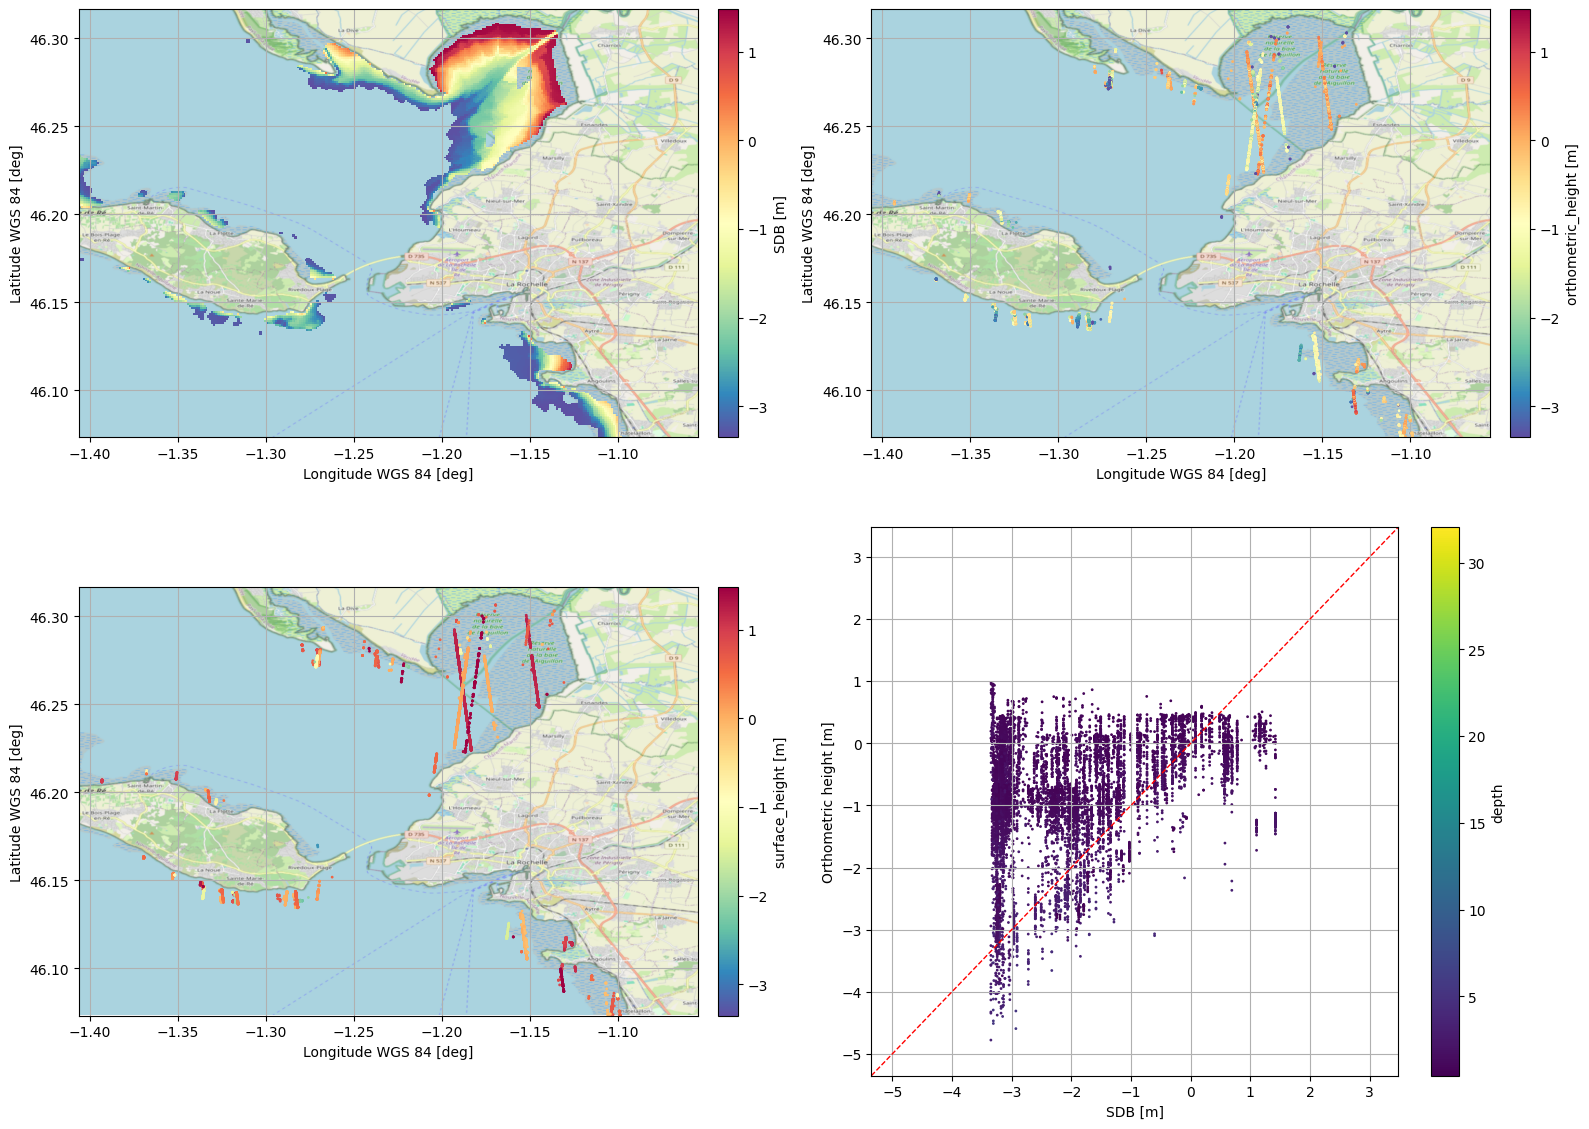

In [ ]:
# Get bounds
bounds = gdf_tile.bounds.values.flatten()
xlim = [bounds[0], bounds[2]]
ylim = [bounds[1], bounds[3]]
vmin = da_sdb.isel(band=0).min() #gdf_sdb[column].quantile(0.1)
vmax = da_sdb.isel(band=0).max() #gdf_sdb[column].quantile(0.9)
vmin_pad = -2
vmax_pad = 2

# Plot maps
fig, axs = rpc.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()
rpc.imshow(da_sdb.isel(band=0).rio.reproject('EPSG:4326'), ax=axs[0], data_style='default',
           cmap='Spectral_r', cbar_kwargs={'label': 'SDB [m]'})
rpc.geometries(gdf_icesat_sdb, ax=axs[1], geom_style='default', column='orthometric_height', markersize=1,
            cmap='Spectral_r', legend=True, legend_kwds={'label': f'orthometric_height [m]'}, vmin=vmin, vmax=vmax)
rpc.geometries(gdf_icesat_sdb, ax=axs[2], geom_style='default', column='surface_height', markersize=1,
            cmap='Spectral_r', legend=True, legend_kwds={'label': f'surface_height [m]'}, vmin=vmin, vmax=vmax)
for ax in axs[:3]:
    rpc.basemap(crs=crs, ax=ax, xlim=xlim, ylim=ylim, map_style='default')
    
gdf_icesat_sdb.plot.scatter(x='sdb', y='orthometric_height', s=1, c='depth', ax=axs[3])
axs[3].set_xlim(vmin+vmin_pad, vmax+vmax_pad)
axs[3].set_ylim(vmin+vmin_pad, vmax+vmax_pad)
axs[3].set_xlabel('SDB [m]')
axs[3].set_ylabel('Orthometric height [m]')
axs[3].plot([vmin+vmin_pad, vmax+vmax_pad], [vmin+vmin_pad, vmax+vmax_pad], color='red', linestyle='--', linewidth=1)
axs[3].grid()
rpc.show(fig=fig)

In [40]:
for file_index in range(gdf_icesat_sdb['file_index'].max() + 1):
    break
    fig, axs = rpc.subplots(1, 2, figsize=(16, 4))
    rpc.geometries(gdf_icesat_sdb[gdf_icesat_sdb['file_index'] == file_index], column='orthometric_height', ax=axs[0], markersize=1,
                cmap='Spectral_r', legend=True, legend_kwds={'label': f'orthometric_height [m]'}, vmin=vmin, vmax=vmax)
    rpc.basemap(crs=crs, ax=axs[0], xlim=xlim, ylim=ylim, map_style='default')
    gdf_icesat_sdb[gdf_icesat_sdb['file_index'] == file_index].plot.scatter(x='sdb', y='orthometric_height', s=1, c='depth', ax=axs[1], cmap='Spectral_r')
    axs[1].plot([vmin+vmin_pad, vmax+vmax_pad], [vmin+vmin_pad, vmax+vmax_pad], color='red', linestyle='--', linewidth=1)
    for ax in axs:
        ax.set_title(f'File index: {file_index}')
    rpc.show(fig=fig)

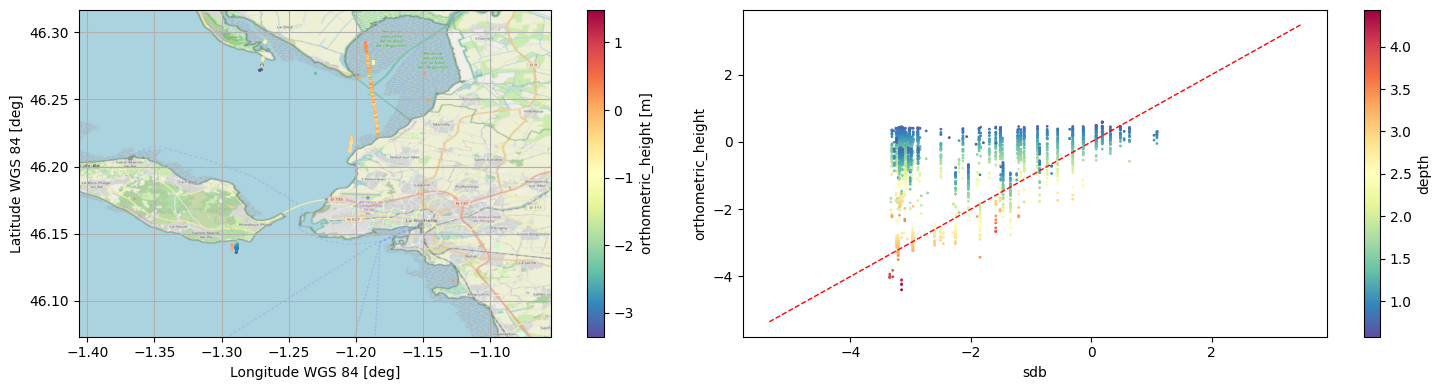

In [41]:
file_indices_dict = {
    'Waddenzee': [48, 52, 53, 55, 57, 63, 67, 69, 70, 71, 175, 188, 214, 223, 224] + [76, 177, 178],
    'Le Mont-Saint-Michel': [8, 9, 15, 75, 78] + [16, 23, 24, 68, 87],
}            
file_indices = file_indices_dict['Waddenzee']

gdf_icesat_sdb['selected'] = (gdf_icesat_sdb['file_index'].isin(file_indices)) & (gdf_icesat_sdb['depth'] < 10)

# Convert to float
gdf_icesat_sdb['selected_float'] = gdf_icesat_sdb['selected'].astype(float)

fig, axs = rpc.subplots(1, 2, figsize=(16, 4))
rpc.geometries(gdf_icesat_sdb[gdf_icesat_sdb['selected']], column='orthometric_height', ax=axs[0], markersize=1,
            cmap='Spectral_r', legend=True, legend_kwds={'label': f'orthometric_height [m]'}, vmin=vmin, vmax=vmax)
rpc.basemap(crs=crs, ax=axs[0], xlim=xlim, ylim=ylim, map_style='default')
gdf_icesat_sdb[gdf_icesat_sdb['selected']].plot.scatter(x='sdb', y='orthometric_height', s=1, c='depth', ax=axs[1], cmap='Spectral_r')
axs[1].plot([vmin+vmin_pad, vmax+vmax_pad], [vmin+vmin_pad, vmax+vmax_pad], color='red', linestyle='--', linewidth=1)
rpc.show(fig=fig)

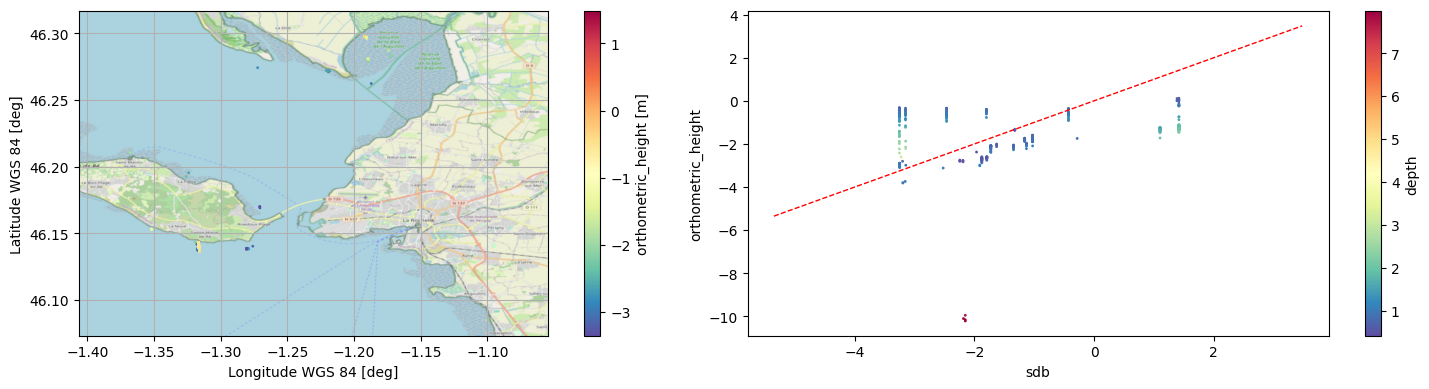

In [50]:
gdf_icesat_sdb['selected'] = (gdf_icesat_sdb['gtsm_waterlevel'] < -1.5) & (gdf_icesat_sdb['depth'] < 10)

# Convert to float
gdf_icesat_sdb['selected_float'] = gdf_icesat_sdb['selected'].astype(float)

fig, axs = rpc.subplots(1, 2, figsize=(16, 4))
rpc.geometries(gdf_icesat_sdb[gdf_icesat_sdb['selected']], column='orthometric_height', ax=axs[0], markersize=1,
            cmap='Spectral_r', legend=True, legend_kwds={'label': f'orthometric_height [m]'}, vmin=vmin, vmax=vmax)
rpc.basemap(crs=crs, ax=axs[0], xlim=xlim, ylim=ylim, map_style='default')
gdf_icesat_sdb[gdf_icesat_sdb['selected']].plot.scatter(x='sdb', y='orthometric_height', s=1, c='depth', ax=axs[1], cmap='Spectral_r')
axs[1].plot([vmin+vmin_pad, vmax+vmax_pad], [vmin+vmin_pad, vmax+vmax_pad], color='red', linestyle='--', linewidth=1)
rpc.show(fig=fig)

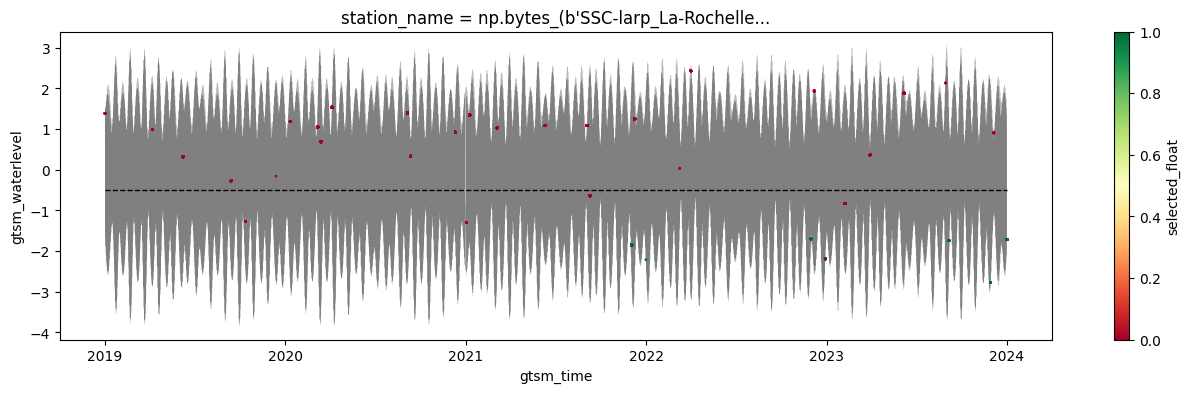

In [51]:
fig, ax = rpc.subplots(figsize=(16, 4))
ds_gtsm_station['waterlevel'].plot.line(ax=ax, linewidth=0.1, color='grey')
gdf_icesat_sdb.plot.scatter(x='gtsm_time', y='gtsm_waterlevel', s=1, c='selected_float', ax=ax, cmap='RdYlGn', zorder=2)
ax.hlines(-0.5, xmin=gdf_icesat_sdb['gtsm_time'].min(), xmax=gdf_icesat_sdb['gtsm_time'].max(), color='black', linestyle='--', linewidth=1)

# TODOS:
* Check area with low turbidity (Florida)
* Check individual tracks
* Check tracks at low tide (link with GTSM)